# 1 Finetuning openai-clip model

In [2]:
!pip install wandb
!pip install openai-clip
!pip install datasets
!pip install torch
!pip install tqdm
!pip install braceexpand ftfy webdataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Created wheel for openai-clip: filename=openai_clip-1.0.1-py3-none-any.whl size=1368605 sha256=8ad8c97433c7432c64e6307e374815eeb1ee7487896072914470d9e2a53c7deb
  Stored in directory: /root/.cache/pip/wheels/ab/49/bc/c2342e8e14878210ba4825cf314a53f2570f6fb18b91fce3cf
Successfully built openai-clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wandb login

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lakshminarayanan-m678 (lakshminarayanan-m678-vellore-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
import clip
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import wandb

wandb.init(project="Finetuning_CLIP", name="new_run_clip_ft1")
device = "cuda" if torch.cuda.is_available() else "cpu"

class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        return img, caption

train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"


class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad():
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()


        # Only projection head is trainable
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
ft_model = CLIPFineTune(model).to(device)
# state_dict = torch.load("/content/drive/MyDrive/COLAB/clip_ft5.pt", map_location=device)
# ft_model.load_state_dict(state_dict)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Freeze CLIP weights (VERY IMPORTANT)
for p in ft_model.clip.parameters():
    p.requires_grad = False

train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestXray(val_csv, preprocess), batch_size=32, shuffle=False)


from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(ft_model.proj.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Training loop
patience_es = 5
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

for epoch in range(50):
    ft_model.train()
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        logits = ft_model(imgs, tok) # correct labels → diagonal alignment
        labels = torch.arange(len(imgs)).to(device)
        loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # After finishing all batches of an epoch
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1} — Current LR: {current_lr}")

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Train Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    ft_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1} Val Loss: {val_loss/len(val_loader):.4f}")
    print("--------------------------------------------------")

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": epoch
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            early_stop = True
            break

    #  SAVE CHECKPOINT EVERY 5 EPOCHS
    if (epoch + 1) % 5 == 0:
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{epoch+1}.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Model saving")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft1.pt')  # Save the model's state dictionary

Epoch 1 — Current LR: 0.001
Epoch 1 Train Loss: 3.4579
Epoch 1 Val Loss: 3.4258
--------------------------------------------------
Epoch 2 — Current LR: 0.001
Epoch 2 Train Loss: 3.4471
Epoch 2 Val Loss: 3.4172
--------------------------------------------------
Epoch 3 — Current LR: 0.001
Epoch 3 Train Loss: 3.4381
Epoch 3 Val Loss: 3.4099
--------------------------------------------------
Epoch 4 — Current LR: 0.001
Epoch 4 Train Loss: 3.4294
Epoch 4 Val Loss: 3.4030
--------------------------------------------------
Epoch 5 — Current LR: 0.001
Epoch 5 Train Loss: 3.4225
Epoch 5 Val Loss: 3.3973
--------------------------------------------------
✅ Saved checkpoint: /content/drive/MyDrive/COLAB/clip_epoch_5.pt
Epoch 6 — Current LR: 0.001
Epoch 6 Train Loss: 3.4146
Epoch 6 Val Loss: 3.3920
--------------------------------------------------
Epoch 7 — Current LR: 0.001
Epoch 7 Train Loss: 3.4092
Epoch 7 Val Loss: 3.3870
--------------------------------------------------
Epoch 8 — Current 

In [ ]:
import clip
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import wandb

wandb.init(project="Finetuning_CLIP", name="new_run_clip_ft2")
device = "cuda" if torch.cuda.is_available() else "cpu"

class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        return img, caption

train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"



class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad():
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()


        # Only projection head is trainable
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

ft_model = CLIPFineTune(model).to(device)
state_dict = torch.load("/content/drive/MyDrive/COLAB/clip_ft1.pt", map_location=device)
ft_model.load_state_dict(state_dict)
for p in ft_model.clip.parameters():
    p.requires_grad = False

train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestXray(val_csv, preprocess), batch_size=32, shuffle=False)


from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(ft_model.proj.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


# Training loop
patience_es = 5        # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

for epoch in range(25):
    ft_model.train()
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        logits = ft_model(imgs, tok)
        # correct labels → diagonal alignment
        labels = torch.arange(len(imgs)).to(device)
        loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # After finishing all batches of an epoch
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+51} — Current LR: {current_lr}")

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+51} Train Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    ft_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+51} Val Loss: {val_loss/len(val_loader):.4f}")
    print("--------------------------------------------------")

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": epoch
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch+51} epochs!")
            early_stop = True
            break


    #  SAVE CHECKPOINT EVERY 5 EPOCHS
    if (epoch + 1) % 5 == 0:
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{epoch+51}.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Model saving")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft2.pt')  # Save the model's state dictionary

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,██▇▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
val_loss,█▇▇▇▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,49
train_loss,3.30552
val_loss,3.31083


Epoch 51 — Current LR: 0.01
Epoch 51 Train Loss: 3.3104
Epoch 51 Val Loss: 3.3094
--------------------------------------------------
Epoch 52 — Current LR: 0.01
Epoch 52 Train Loss: 3.2980
Epoch 52 Val Loss: 3.3071
--------------------------------------------------
Epoch 53 — Current LR: 0.01
Epoch 53 Train Loss: 3.2933
Epoch 53 Val Loss: 3.2997
--------------------------------------------------
Epoch 54 — Current LR: 0.01
Epoch 54 Train Loss: 3.2856
Epoch 54 Val Loss: 3.2980
--------------------------------------------------
Epoch 55 — Current LR: 0.01
Epoch 55 Train Loss: 3.2786
Epoch 55 Val Loss: 3.2972
--------------------------------------------------
✅ Saved checkpoint: /content/drive/MyDrive/COLAB/clip_epoch_55.pt
Epoch 56 — Current LR: 0.01
Epoch 56 Train Loss: 3.2758
Epoch 56 Val Loss: 3.2956
--------------------------------------------------
Epoch 57 — Current LR: 0.01
Epoch 57 Train Loss: 3.2685
Epoch 57 Val Loss: 3.2967
--------------------------------------------------
Epo

In [ ]:
import clip
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import wandb

wandb.init(project="Finetuning_CLIP", name="new_run_clip_ft3")
device = "cuda" if torch.cuda.is_available() else "cpu"


# Dataset
class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        return img, caption

train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"




class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad():
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()


        # Only projection head is trainable
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

ft_model = CLIPFineTune(model).to(device)
state_dict = torch.load("/content/drive/MyDrive/COLAB/clip_ft2.pt", map_location=device)
ft_model.load_state_dict(state_dict)
for p in ft_model.clip.parameters():
    p.requires_grad = False

train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestXray(val_csv, preprocess), batch_size=32, shuffle=False)


from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(ft_model.proj.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


# Training loop
patience_es = 5        # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

for epoch in range(25):
    ft_model.train()
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        logits = ft_model(imgs, tok)
        # correct labels → diagonal alignment
        labels = torch.arange(len(imgs)).to(device)
        loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # After finishing all batches of an epoch
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+76} — Current LR: {current_lr}")

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+76} Train Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    ft_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+51} Val Loss: {val_loss/len(val_loader):.4f}")
    print("--------------------------------------------------")

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": epoch
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch+76} epochs!")
            early_stop = True
            break


    #  SAVE CHECKPOINT EVERY 5 EPOCHS
    if (epoch + 1) % 5 == 0:
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{epoch+76}.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Model saving")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft3.pt')  # Save the model's state dictionary

epoch,▁
learning_rate,▁
+2,...
epoch,76
learning_rate,1e-05
train_loss,nan
val_loss,nan


Epoch 76 — Current LR: 0.01
Epoch 76 Train Loss: 3.2308
Epoch 51 Val Loss: 3.2876
--------------------------------------------------
Epoch 77 — Current LR: 0.01
Epoch 77 Train Loss: 3.2235
Epoch 52 Val Loss: 3.2848
--------------------------------------------------
Epoch 78 — Current LR: 0.01
Epoch 78 Train Loss: 3.2245
Epoch 53 Val Loss: 3.2893
--------------------------------------------------
Epoch 79 — Current LR: 0.01
Epoch 79 Train Loss: 3.2270
Epoch 54 Val Loss: 3.2864
--------------------------------------------------
Epoch 80 — Current LR: 0.01
Epoch 80 Train Loss: 3.2201
Epoch 55 Val Loss: 3.2843
--------------------------------------------------
✅ Saved checkpoint: /content/drive/MyDrive/COLAB/clip_epoch_80.pt
Epoch 81 — Current LR: 0.01
Epoch 81 Train Loss: 3.2186
Epoch 56 Val Loss: 3.2869
--------------------------------------------------
Epoch 82 — Current LR: 0.01
Epoch 82 Train Loss: 3.2169
Epoch 57 Val Loss: 3.2886
--------------------------------------------------
Epo

In [ ]:
import clip
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import wandb

wandb.init(project="Finetuning_CLIP", name="new_run_clip_ft4")
device = "cuda" if torch.cuda.is_available() else "cpu"


# Dataset
class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        return img, caption

train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"




class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad():
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()


        # Only projection head is trainable
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

ft_model = CLIPFineTune(model).to(device)
state_dict = torch.load("/content/drive/MyDrive/COLAB/clip_epoch_80.pt", map_location=device)
ft_model.load_state_dict(state_dict)
for p in ft_model.clip.parameters():
    p.requires_grad = False

train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestXray(val_csv, preprocess), batch_size=32, shuffle=False)


from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(ft_model.proj.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


# Training loop
patience_es = 10        # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

for epoch in range(25):
    ft_model.train()
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        logits = ft_model(imgs, tok)
        # correct labels → diagonal alignment
        labels = torch.arange(len(imgs)).to(device)
        loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # After finishing all batches of an epoch
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+81} — Current LR: {current_lr}")

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+81} Train Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    ft_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+81} Val Loss: {val_loss/len(val_loader):.4f}")
    print("--------------------------------------------------")

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": epoch
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch+81} epochs!")
            early_stop = True
            break


    #  SAVE CHECKPOINT EVERY 5 EPOCHS
    if (epoch + 1) % 5 == 0:
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{epoch+81}.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Model saving")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft4.pt')  # Save the model's state dictionary

epoch,▁▂▄▅▇█
train_loss,▆█▃▂▄▁
val_loss,▁█▃▆▃▃
epoch,5
train_loss,3.20803
val_loss,3.28364


Epoch 81 — Current LR: 0.001
Epoch 81 Train Loss: 3.2116
Epoch 81 Val Loss: 3.2837
--------------------------------------------------
Epoch 82 — Current LR: 0.001
Epoch 82 Train Loss: 3.2118
Epoch 82 Val Loss: 3.2848
--------------------------------------------------
Epoch 83 — Current LR: 0.001
Epoch 83 Train Loss: 3.2113
Epoch 83 Val Loss: 3.2842
--------------------------------------------------
Epoch 84 — Current LR: 0.001
Epoch 84 Train Loss: 3.2130
Epoch 84 Val Loss: 3.2841
--------------------------------------------------
Epoch 85 — Current LR: 0.001
Epoch 85 Train Loss: 3.2108
Epoch 85 Val Loss: 3.2842
--------------------------------------------------
✅ Saved checkpoint: /content/drive/MyDrive/COLAB/clip_epoch_85.pt
Epoch 86 — Current LR: 0.0001
Epoch 86 Train Loss: 3.2102
Epoch 86 Val Loss: 3.2841
--------------------------------------------------
Epoch 87 — Current LR: 0.0001
Epoch 87 Train Loss: 3.2072
Epoch 87 Val Loss: 3.2842
---------------------------------------------

# 2 Inference on Test Data and Evaluation


## 2.1 Test with fine_tuned model weights

In [ ]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import clip

# Try importing visualization libraries (optional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
    HAS_PLOTTING = True
except ImportError:
    HAS_PLOTTING = False
    print("Warning: Matplotlib, Seaborn, or Scikit-learn not found. Plotting and detailed metrics will be skipped.")

# Disease classes we're working with
SELECTED_CLASSES = ["atelectasis", "mass", "effusion", "infiltration", "nodule"]

# Text descriptions for zero-shot classification
TEXT_PROMPTS = [
    "Posteroanterior view chest X-ray showing atelectasis.",
    "Posteroanterior view chest X-ray showing mass.",
    "Posteroanterior view chest X-ray showing effusion.",
    "Posteroanterior view chest X-ray showing infiltration.",
    "Posteroanterior view chest X-ray showing nodule."
]

# Mapping for extracting ground truth class from caption
caption_to_class_map = {
    "Posteroanterior view chest X-ray showing atelectasis.": "atelectasis",
    "Posteroanterior view chest X-ray showing mass.": "mass",
    "Posteroanterior view chest X-ray showing effusion.": "effusion",
    "Posteroanterior view chest X-ray showing infiltration.": "infiltration",
    "Posteroanterior view chest X-ray showing nodule.": "nodule"
}

def get_ground_truth_class(caption: str) -> str:
    """Extracts the ground truth class from a given caption."""
    for prompt_key, cls_name in caption_to_class_map.items():
        if prompt_key.lower() in caption.lower():
            return cls_name
    return "UNKNOWN" # Default if no match found


def plot_confusion_matrix(y_true: list, y_pred: list, classes: list, title: str, output_path: str = 'confusion_matrix.png'):
    """Generate and save confusion matrix visualization."""
    if not HAS_PLOTTING:
        print("Cannot plot confusion matrix: plotting libraries not available.")
        return

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()

def print_single_prediction(image_path: str, predicted_class: str, confidence: float,
                           probabilities: list, model_name: str):
    """Display prediction results for a single image"""
    print(f"\n{'='*60}")
    print(f"{model_name} - {os.path.basename(image_path)}")
    print(f"Predicted: {predicted_class} (Confidence: {confidence*100:.2f}%)")
    print(f"{'='*60}")
    print("Probabilities for all classes:")
    for cls, prob in zip(SELECTED_CLASSES, probabilities):
        bar = "█" * int(prob * 40)
        print(f"  {cls:12s}: {prob*100:5.1f}% {bar}")
    print(f"{'='*60}\n")

# Redefine the Dataset class if not already in scope (or ensure it's from a previous cell)
class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)
        caption = row["Caption"]
        return img, caption


In [ ]:
class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad(): # Keep CLIP base model frozen during inference
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()

        # Apply the projection head
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the base CLIP model and its preprocessing function
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

# Instantiate your fine-tuned model wrapper
ft_model = CLIPFineTune(model).to(device)

# Load the state dictionary of your best fine-tuned model
# Using 'clip_ft_best.pt' as it stores the model with the best validation loss
try:
    model_path = '/content/drive/MyDrive/COLAB/clip_epoch_75.pt'
    ft_model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Successfully loaded fine-tuned model from {model_path}")
except FileNotFoundError:
    print(f"Error: Model checkpoint not found at {model_path}. Please ensure the file exists.")
except Exception as e:
    print(f"Error loading model state dictionary: {e}")

ft_model.eval()


Using device: cuda
Successfully loaded fine-tuned model from /content/drive/MyDrive/COLAB/clip_epoch_75.pt


CLIPFineTune(
  (clip): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizabl

Loaded 343 samples from val.csv

Starting inference on val dataset...
Processed 50/343 test samples...
Processed 100/343 test samples...
Processed 150/343 test samples...
Processed 200/343 test samples...
Processed 250/343 test samples...
Processed 300/343 test samples...
Processed 343/343 test samples...

Inference complete.

--- Evaluation Results ---
Overall Accuracy: 37.32%

Classification Report:
              precision    recall  f1-score   support

 atelectasis       0.34      0.39      0.36        61
        mass       0.27      0.20      0.23        64
    effusion       0.49      0.57      0.53        74
infiltration       0.37      0.39      0.38        75
      nodule       0.34      0.29      0.31        69

    accuracy                           0.37       343
   macro avg       0.36      0.37      0.36       343
weighted avg       0.36      0.37      0.37       343



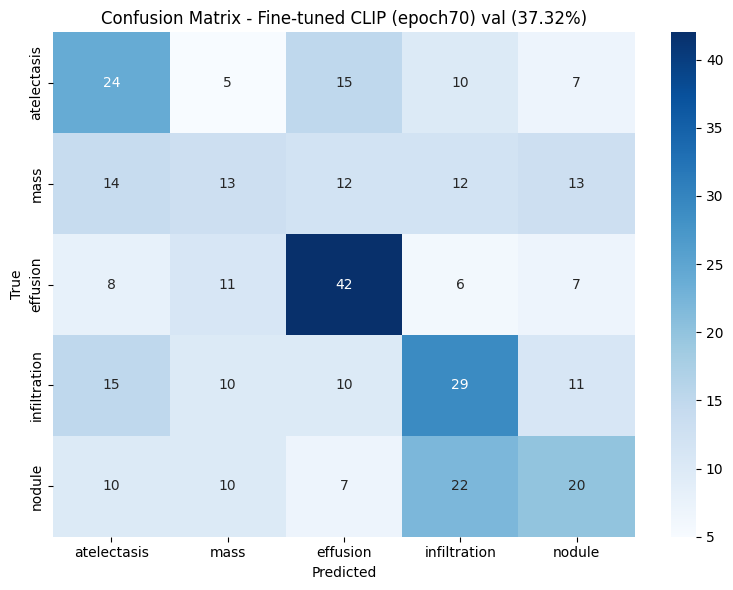

Confusion matrix saved to results/confusion_matrix_finetuned_clip_epoch75_val.png


In [ ]:
@torch.no_grad()
def predict_image_with_ft_model(image_path: str, model_ft: nn.Module, preprocess_fn, tokenizer_fn, device: str):
    """
    Predicts the disease class for a single X-ray image using the fine-tuned CLIP model.
    Returns predicted class, confidence score, and probability for all classes.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image_input = preprocess_fn(image).unsqueeze(0).to(device)

    # Tokenize the predefined text prompts for classification
    text_inputs = tokenizer_fn(TEXT_PROMPTS).to(device)

    # Get logits from the fine-tuned model
    logits = model_ft(image_input, text_inputs)

    # Convert logits to probabilities
    probs = logits.softmax(dim=-1).cpu().numpy()[0]

    # Get the predicted class (highest probability)
    pred_idx = int(np.argmax(probs))
    return SELECTED_CLASSES[pred_idx], float(probs[pred_idx]), probs.tolist()



# Batch Inference and Evaluation
test_csv_path = r"/content/drive/MyDrive/COLAB/val.csv"

if not os.path.exists(test_csv_path):
    print(f"Error: test.csv not found at {test_csv_path}. Please ensure the file exists and is correctly path-mapped.")
else:
    test_df = pd.read_csv(test_csv_path)
    print(f"Loaded {len(test_df)} samples from val.csv")

    y_true_labels = []
    y_pred_labels = []
    all_confidences = []

    print("\nStarting inference on val dataset...")
    for idx, row in test_df.iterrows():
        img_path = row["ImagePath"]
        true_caption = row["Caption"]

        # Get ground truth class from caption
        ground_truth_class = get_ground_truth_class(true_caption)

        if not os.path.exists(img_path):
            print(f"Skipping image {img_path}: File not found.")
            continue

        try:
            predicted_class, confidence, probabilities = predict_image_with_ft_model(
                img_path, ft_model, preprocess, clip.tokenize, device
            )

            if ground_truth_class != "UNKNOWN": # Only include if we found a valid ground truth class
                y_true_labels.append(ground_truth_class)
                y_pred_labels.append(predicted_class)
                all_confidences.append(confidence)

            if (idx + 1) % 50 == 0 or (idx + 1) == len(test_df):
                print(f"Processed {idx + 1}/{len(test_df)} test samples...")

        except Exception as e:
            print(f"Error processing image {img_path}: {e}")

    print("\nInference complete.")

    if y_true_labels and y_pred_labels:
        # Calculate and print metrics
        accuracy = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\n--- Evaluation Results ---")
        print(f"Overall Accuracy: {accuracy*100:.2f}%")
        print("\nClassification Report:")
        print(classification_report(y_true_labels, y_pred_labels, labels=SELECTED_CLASSES, zero_division=0))

        # Plot confusion matrix
        if HAS_PLOTTING:
            os.makedirs('results', exist_ok=True)
            plot_confusion_matrix(y_true_labels, y_pred_labels, SELECTED_CLASSES,
                                  f'Confusion Matrix - Fine-tuned CLIP (epoch70) val ({accuracy*100:.2f}%)',
                                  output_path='results/confusion_matrix_finetuned_clip_epoch75_val.png')
            print(f"Confusion matrix saved to results/confusion_matrix_finetuned_clip_epoch75_val.png")
        else:
            print("Cannot generate confusion matrix plot: plotting libraries not available.")

    else:
        print("No valid samples processed for evaluation.")


## 2.2 Test with zeroshot model

In [4]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import clip

# Try importing visualization libraries (optional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
    HAS_PLOTTING = True
except ImportError:
    HAS_PLOTTING = False
    print("Warning: Matplotlib, Seaborn, or Scikit-learn not found. Plotting and detailed metrics will be skipped.")

# Disease classes we're working with
SELECTED_CLASSES = ["atelectasis", "mass", "effusion", "infiltration", "nodule"]

# Text descriptions for zero-shot classification
TEXT_PROMPTS = [
    "Posteroanterior view chest X-ray showing atelectasis.",
    "Posteroanterior view chest X-ray showing mass.",
    "Posteroanterior view chest X-ray showing effusion.",
    "Posteroanterior view chest X-ray showing infiltration.",
    "Posteroanterior view chest X-ray showing nodule."
]

# Mapping for extracting ground truth class from caption
caption_to_class_map = {
    "Posteroanterior view chest X-ray showing atelectasis.": "atelectasis",
    "Posteroanterior view chest X-ray showing mass.": "mass",
    "Posteroanterior view chest X-ray showing effusion.": "effusion",
    "Posteroanterior view chest X-ray showing infiltration.": "infiltration",
    "Posteroanterior view chest X-ray showing nodule.": "nodule"
}

def get_ground_truth_class(caption: str) -> str:
    """Extracts the ground truth class from a given caption."""
    for prompt_key, cls_name in caption_to_class_map.items():
        if prompt_key.lower() in caption.lower():
            return cls_name
    return "UNKNOWN" # Default if no match found


def plot_confusion_matrix(y_true: list, y_pred: list, classes: list, title: str, output_path: str = 'confusion_matrix.png'):
    """Generate and save confusion matrix visualization."""
    if not HAS_PLOTTING:
        print("Cannot plot confusion matrix: plotting libraries not available.")
        return

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()

def print_single_prediction(image_path: str, predicted_class: str, confidence: float,
                           probabilities: list, model_name: str):
    """Display prediction results for a single image"""
    print(f"\n{'='*60}")
    print(f"{model_name} - {os.path.basename(image_path)}")
    print(f"Predicted: {predicted_class} (Confidence: {confidence*100:.2f}%)")
    print(f"{'='*60}")
    print("Probabilities for all classes:")
    for cls, prob in zip(SELECTED_CLASSES, probabilities):
        bar = "█" * int(prob * 40)
        print(f"  {cls:12s}: {prob*100:5.1f}% {bar}")
    print(f"{'='*60}\n")

# Redefine the Dataset class if not already in scope (or ensure it's from a previous cell)
class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)
        caption = row["Caption"]
        return img, caption


In [5]:
class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        with torch.no_grad(): # Keep CLIP base model frozen during inference
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()

        # Apply the projection head
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the base CLIP model and its preprocessing function
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

# Instantiate your fine-tuned model wrapper
ft_model = CLIPFineTune(model).to(device)

# Load the state dictionary of your best fine-tuned model
# Using 'clip_ft_best.pt' as it stores the model with the best validation loss
# try:
#     model_path = '/content/drive/MyDrive/COLAB/clip_epoch_75.pt'
#     ft_model.load_state_dict(torch.load(model_path, map_location=device))
#     print(f"Successfully loaded fine-tuned model from {model_path}")
# except FileNotFoundError:
#     print(f"Error: Model checkpoint not found at {model_path}. Please ensure the file exists.")
#     # Optionally, you might want to load a different checkpoint or handle this error gracefully
# except Exception as e:
#     print(f"Error loading model state dictionary: {e}")

ft_model.eval() # Set the model to evaluation mode


Using device: cpu


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 227MiB/s]


CLIPFineTune(
  (clip): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizabl

Loaded 343 samples from test.csv

Starting inference on test dataset...
Processed 50/343 test samples...
Processed 100/343 test samples...
Processed 150/343 test samples...
Processed 200/343 test samples...
Processed 250/343 test samples...
Processed 300/343 test samples...
Processed 343/343 test samples...

Inference complete.

--- Evaluation Results ---
Overall Accuracy: 21.57%

Classification Report:
              precision    recall  f1-score   support

 atelectasis       0.00      0.00      0.00        75
        mass       0.22      1.00      0.35        74
    effusion       0.00      0.00      0.00        67
infiltration       0.00      0.00      0.00        65
      nodule       0.00      0.00      0.00        62

    accuracy                           0.22       343
   macro avg       0.04      0.20      0.07       343
weighted avg       0.05      0.22      0.08       343



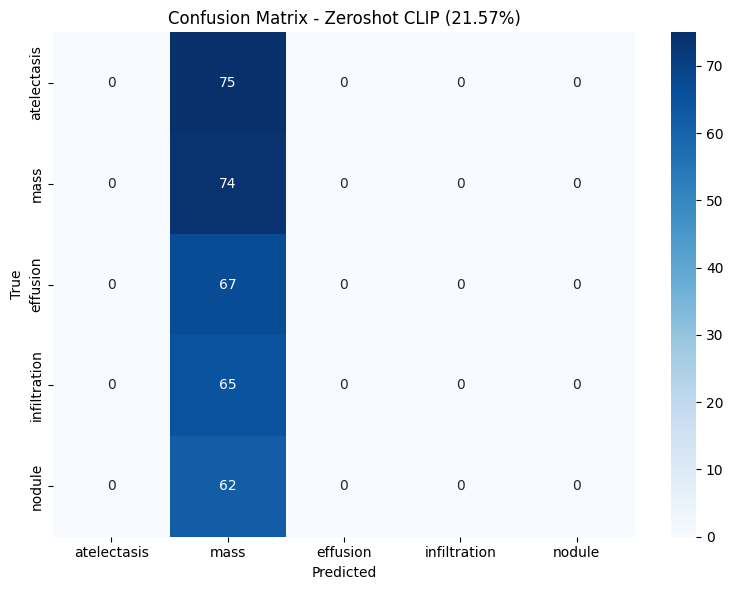

Confusion matrix saved to results/confusion_matrix_zeroshot.png


In [6]:
@torch.no_grad()
def predict_image_with_ft_model(image_path: str, model_ft: nn.Module, preprocess_fn, tokenizer_fn, device: str):
    """
    Predicts the disease class for a single X-ray image using the fine-tuned CLIP model.
    Returns predicted class, confidence score, and probability for all classes.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image_input = preprocess_fn(image).unsqueeze(0).to(device)

    # Tokenize the predefined text prompts for classification
    text_inputs = tokenizer_fn(TEXT_PROMPTS).to(device)

    # Get logits from the fine-tuned model
    logits = model_ft(image_input, text_inputs)

    # Convert logits to probabilities
    probs = logits.softmax(dim=-1).cpu().numpy()[0]

    # Get the predicted class (highest probability)
    pred_idx = int(np.argmax(probs))
    return SELECTED_CLASSES[pred_idx], float(probs[pred_idx]), probs.tolist()



# Batch Inference and Evaluation
test_csv_path = r"/content/drive/MyDrive/COLAB/test.csv"

if not os.path.exists(test_csv_path):
    print(f"Error: test.csv not found at {test_csv_path}. Please ensure the file exists and is correctly path-mapped.")
else:
    test_df = pd.read_csv(test_csv_path)
    print(f"Loaded {len(test_df)} samples from test.csv")

    y_true_labels = []
    y_pred_labels = []
    all_confidences = []

    print("\nStarting inference on test dataset...")
    for idx, row in test_df.iterrows():
        img_path = row["ImagePath"]
        true_caption = row["Caption"]

        # Get ground truth class from caption
        ground_truth_class = get_ground_truth_class(true_caption)

        if not os.path.exists(img_path):
            print(f"Skipping image {img_path}: File not found.")
            continue

        try:
            predicted_class, confidence, probabilities = predict_image_with_ft_model(
                img_path, ft_model, preprocess, clip.tokenize, device
            )

            if ground_truth_class != "UNKNOWN": # Only include if we found a valid ground truth class
                y_true_labels.append(ground_truth_class)
                y_pred_labels.append(predicted_class)
                all_confidences.append(confidence)

            if (idx + 1) % 50 == 0 or (idx + 1) == len(test_df):
                print(f"Processed {idx + 1}/{len(test_df)} test samples...")

        except Exception as e:
            print(f"Error processing image {img_path}: {e}")

    print("\nInference complete.")

    if y_true_labels and y_pred_labels:
        # Calculate and print metrics
        accuracy = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\n--- Evaluation Results ---")
        print(f"Overall Accuracy: {accuracy*100:.2f}%")
        print("\nClassification Report:")
        print(classification_report(y_true_labels, y_pred_labels, labels=SELECTED_CLASSES, zero_division=0))

        # Plot confusion matrix
        if HAS_PLOTTING:
            os.makedirs('results', exist_ok=True)
            plot_confusion_matrix(y_true_labels, y_pred_labels, SELECTED_CLASSES,
                                  f'Confusion Matrix - Zeroshot CLIP ({accuracy*100:.2f}%)',
                                  output_path='results/confusion_matrix_zeroshot.png')
            print(f"Confusion matrix saved to results/confusion_matrix_zeroshot.png")
        else:
            print("Cannot generate confusion matrix plot: plotting libraries not available.")

    else:
        print("No valid samples processed for evaluation.")


# 3 Trying out layer wise Learning rates

## 3.1 Resuming epoch with updates finetuning

In [ ]:
import clip
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau

wandb.init(project="Finetuning_CLIP", name="new_run_clip_ft3")
device = "cuda" if torch.cuda.is_available() else "cpu"


# Dataset

class ChestXray(Dataset):
    def __init__(self, csv_path, preprocess):
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        return img, caption

train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"


 (modified for partial unfreezing)

class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.proj = nn.Linear(512, 512)

    def forward(self, images, text_tokens):
        # Removed torch.no_grad() here to allow gradients to flow for unfrozen CLIP layers
        img_f = self.clip.encode_image(images)
        txt_f = self.clip.encode_text(text_tokens)

        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=1, keepdim=True)
        img_f = img_f.float()
        txt_f = txt_f.float()

        # Only projection head is trainable (initially, others are frozen)
        img_f = self.proj(img_f)

        logits = img_f @ txt_f.t()
        return logits

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
ft_model = CLIPFineTune(model).to(device)

# Load the previously fine-tuned model state
try:
    state_dict = torch.load("/content/drive/MyDrive/COLAB/clip_ft2.pt", map_location=device)
    ft_model.load_state_dict(state_dict)
    print("Successfully loaded previous fine-tuned model (clip_ft2.pt).")
except FileNotFoundError:
    print("Error: clip_ft2.pt not found. Starting partial fine-tuning from initial CLIP weights.")
except Exception as e:
    print(f"Error loading model state dictionary: {e}. Starting partial fine-tuning from initial CLIP weights.")


# Freeze all CLIP parameters first
for p in ft_model.clip.parameters():
    p.requires_grad = False

# Partial unfreezing: Set requires_grad=True for the last two TransformerBlock layers
# of both the visual and text encoders

# Visual encoder (Image Transformer)
print("Unfreezing last 2 layers of CLIP visual encoder...")
for i, block in enumerate(ft_model.clip.visual.transformer.resblocks):
    if i >= len(ft_model.clip.visual.transformer.resblocks) - 2:
        for p in block.parameters():
            p.requires_grad = True
        print(f"  Unfrozen visual block {i}")

# Text encoder (Text Transformer)
print("Unfreezing last 2 layers of CLIP text encoder...")
for i, block in enumerate(ft_model.clip.transformer.resblocks):
    if i >= len(ft_model.clip.transformer.resblocks) - 2:
        for p in block.parameters():
            p.requires_grad = True
        print(f"  Unfrozen text block {i}")


train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestXray(val_csv, preprocess), batch_size=32, shuffle=False)

# Configure optimizer with layer-wise learning rates
optimizer_grouped_parameters = [
    {'params': ft_model.proj.parameters(), 'lr': 1e-5}, # Higher LR for the projection head
    {'params': ft_model.clip.visual.transformer.resblocks[-1].parameters(), 'lr': 1e-6},
    {'params': ft_model.clip.visual.transformer.resblocks[-2].parameters(), 'lr': 1e-6},
    {'params': ft_model.clip.transformer.resblocks[-1].parameters(), 'lr': 1e-6},
    {'params': ft_model.clip.transformer.resblocks[-2].parameters(), 'lr': 1e-6}
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters)

loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


# Training loop (continuation)

patience_es = 5        # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

START_EPOCH = 76 # Starting epoch number for this run
NUM_EPOCHS = 25  # Number of additional epochs

for epoch_idx in range(NUM_EPOCHS):
    current_global_epoch = START_EPOCH + epoch_idx
    ft_model.train() # Set model to training mode
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        logits = ft_model(imgs, tok)
        labels = torch.arange(len(imgs)).to(device)
        loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {current_global_epoch} — Current LR: {current_lr}")

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {current_global_epoch} Train Loss: {avg_train_loss:.4f}")

    # Validation
    ft_model.eval() # Set model to evaluation mode
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {current_global_epoch} Val Loss: {avg_val_loss:.4f}")
    print("--------------------------------------------------")

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": current_global_epoch,
        "learning_rate": current_lr
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best.pt')
        print(f"Saved best model checkpoint to /content/drive/MyDrive/COLAB/clip_ft_best.pt (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {current_global_epoch} epochs!")
            early_stop = True
            break


    #  SAVE CHECKPOINT EVERY 5 EPOCHS

    if (current_global_epoch) % 5 == 0: # Save at epoch 75, 80, 85, ..., 100
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{current_global_epoch}.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Model saving")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft3.pt')  # Save the model's state dictionary
print("Final model saved to /content/drive/MyDrive/COLAB/clip_ft3.pt")

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▆▆▇▅▅▄▄▃▁
val_loss,▄▁▅▃▁▃▅█▃▁
epoch,9
train_loss,3.2047
val_loss,3.28462


Successfully loaded previous fine-tuned model (clip_ft2.pt).
Unfreezing last 2 layers of CLIP visual encoder...
  Unfrozen visual block 10
  Unfrozen visual block 11
Unfreezing last 2 layers of CLIP text encoder...
  Unfrozen text block 10
  Unfrozen text block 11
Epoch 76 — Current LR: 1e-05
Epoch 76 Train Loss: nan
Epoch 76 Val Loss: nan
--------------------------------------------------
Epoch 77 — Current LR: 1e-05
Epoch 77 Train Loss: nan
Epoch 77 Val Loss: nan
--------------------------------------------------
Epoch 78 — Current LR: 1e-05
Epoch 78 Train Loss: nan
Epoch 78 Val Loss: nan
--------------------------------------------------
Epoch 79 — Current LR: 1e-05
Epoch 79 Train Loss: nan
Epoch 79 Val Loss: nan
--------------------------------------------------
Epoch 80 — Current LR: 1.0000000000000002e-06
Epoch 80 Train Loss: nan
Epoch 80 Val Loss: nan
--------------------------------------------------
Early stopping triggered after 80 epochs!
Model saving
Final model saved to /c

**Reasoning**:
The previous training run resulted in `nan` losses from the very first epoch, indicating a critical issue preventing stable training. This step aims to diagnose the root cause by making the data loading more robust, adding `nan`/`inf` checks within the model's forward pass, and enabling PyTorch's anomaly detection for detailed tracebacks during backpropagation. This will provide necessary information to fix the underlying problem.



In [ ]:
import clip
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
# from datasets import load_dataset # Use this if loading from Hugging Face
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- 1. SETUP AND WANDB INITIALIZATION ---
wandb.init(project="Finetuning_CLIP", name="clip_lrlr_run")
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. DATASET (Based on your provided notebook structure) ---
class ChestXray(Dataset):
    """
    Custom Dataset to load images and captions from a CSV file.
    Assumes CSV has 'ImagePath' and 'Caption' columns.
    """
    def __init__(self, csv_path, preprocess):
        # NOTE: Make sure the paths are correct for your environment (e.g., Colab/Drive)
        self.data = pd.read_csv(csv_path)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["ImagePath"]).convert("RGB")
        img = self.preprocess(img)

        caption = row["Caption"]
        # CLIP's tokenize handles the text preprocessing
        return img, caption

# Define your data paths (adjust these paths as needed)
train_csv = r"/content/drive/MyDrive/COLAB/train.csv"
val_csv   = r"/content/drive/MyDrive/COLAB/val.csv"


# --- 3. MODEL ARCHITECTURE FOR PARTIAL FINE-TUNING ---
# --- 3. MODEL ARCHITECTURE FOR PARTIAL FINE-TUNING (FINAL FIX) ---
class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.epsilon = 1e-6
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, images, text_tokens):
        with torch.no_grad():
            images = images.to(torch.float32)

            # Allow gradients to flow through CLIP model for partial fine-tuning
            img_f = self.clip.encode_image(images)
            txt_f = self.clip.encode_text(text_tokens)

        # 🛑 DEBUG CHECK 1: Check features right after encoder
        if torch.isnan(img_f).any() or torch.isinf(img_f).any():
            # This check will only hit if the float32 cast failed to fix it.
            raise RuntimeError("CRITICAL FAILURE: NaN/Inf detected in Image Features even after float32 cast. Reduce LR further or check model type.")
        if torch.isnan(txt_f).any() or torch.isinf(txt_f).any():
            raise RuntimeError("NaN/Inf detected in Text Features.")

        # Normalization with Epsilon (self.epsilon)
        img_norm = img_f.norm(dim=1, keepdim=True)
        txt_norm = txt_f.norm(dim=1, keepdim=True)

        img_f = img_f / (img_norm + self.epsilon)
        txt_f = txt_f / (txt_norm + self.epsilon)

        img_f = img_f.float()
        txt_f = txt_f.float()

        # Pass image features through the trainable projection head
        img_f = self.proj(img_f)

        # Compute cosine similarity (dot product of normalized features)
        logits = img_f @ txt_f.t()

        # 🛑 DEBUG CHECK 3: Check Logits before returning
        if torch.isnan(logits).any() or torch.isinf(logits).any():
            raise RuntimeError("NaN/Inf detected in Logits (dot product result).")

        return logits

# Load CLIP model and preprocessing function
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
ft_model = CLIPFineTune(model).to(device)


# --- 4. PARTIAL UNFREEZING OF LAYERS ---

# 4a. Freeze ALL CLIP parameters initially (excluding the new projection head 'proj')
for p in ft_model.clip.parameters():
    p.requires_grad = False

# ViT-B/32 has 12 transformer blocks. We unfreeze the last 2 (indices 10 and 11).
NUM_LAYERS_TO_UNFREEZE = 2
VISUAL_BLOCKS = ft_model.clip.visual.transformer.resblocks
TEXT_BLOCKS   = ft_model.clip.transformer.resblocks
START_INDEX = len(VISUAL_BLOCKS) - NUM_LAYERS_TO_UNFREEZE

print(f"Unfreezing last {NUM_LAYERS_TO_UNFREEZE} layers of CLIP visual encoder...")
for i in range(START_INDEX, len(VISUAL_BLOCKS)):
    for name, param in VISUAL_BLOCKS[i].named_parameters():
        param.requires_grad = True
        print(f"  Unfrozen visual layer: block {i}, param {name}")

print(f"Unfreezing last {NUM_LAYERS_TO_UNFREEZE} layers of CLIP text encoder...")
for i in range(START_INDEX, len(TEXT_BLOCKS)):
    for name, param in TEXT_BLOCKS[i].named_parameters():
        param.requires_grad = True
        print(f"  Unfrozen text layer: block {i}, param {name}")

# --- 5. LAYER-WISE LEARNING RATES (LRLR) OPTIMIZER SETUP (REVISED) ---

# BASE_LR and HEAD_LR are drastically reduced to prevent numerical overflow
# in the first step of the partially fine-tuned ViT encoder.

# Base learning rate for the unfrozen encoder layers
BASE_LR = 1e-9 # DRASCTIC REDUCTION (e.g., from 1e-7)
# Higher learning rate for the newly introduced projection head
HEAD_LR = 1e-8 # DRASCTIC REDUCTION (e.g., from 1e-6)
# An even lower rate for slightly deeper unfrozen layer
DEEPER_LR = 0.5 * BASE_LR # Now 5e-10

# Group parameters and assign a specific learning rate to each group
optimizer_grouped_parameters = [
    # Group 1: New Projection Head (Highest LR: 1e-8)
    {'params': ft_model.proj.parameters(), 'lr': HEAD_LR, 'weight_decay': 0.01},

    # Group 2: Outermost Unfrozen Layers (Block -1) (Base LR: 1e-9)
    {'params': VISUAL_BLOCKS[-1].parameters(), 'lr': BASE_LR, 'weight_decay': 0.01},
    {'params': TEXT_BLOCKS[-1].parameters(), 'lr': BASE_LR, 'weight_decay': 0.01},

    # Group 3: Inner Unfrozen Layers (Block -2) (Deeper LR: 5e-10)
    {'params': VISUAL_BLOCKS[-2].parameters(), 'lr': DEEPER_LR, 'weight_decay': 0.01},
    {'params': TEXT_BLOCKS[-2].parameters(), 'lr': DEEPER_LR, 'weight_decay': 0.01},
]

# Use AdamW for fine-tuning
optimizer = optim.AdamW(optimizer_grouped_parameters)

# ... (rest of the setup)

# Setup Loss Function and LR Scheduler
loss_fn = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Load data loaders
train_loader = DataLoader(ChestXray(train_csv, preprocess), batch_size=8, shuffle=True)
val_loader = DataLoader(ChestXray(val_csv, preprocess), batch_size=8, shuffle=False)
# --- 6. TRAINING LOOP ---
patience_es = 5
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False
NUM_EPOCHS = 5 # Set total number of epochs

for epoch in range(NUM_EPOCHS):
    ft_model.train()
    total_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        tok = clip.tokenize(list(caps)).to(device)

        # Calculate logits
        logits = ft_model(imgs, tok)

        # 💡 CRITICAL STABILITY FIX: Scale logits down by a constant factor
        # (e.g., 100.0) to prevent overflow in LogSoftmax (CrossEntropyLoss).
        # This mimics the dampening effect of a temperature parameter.
        SCALE_FACTOR = 100.0
        scaled_logits = logits / SCALE_FACTOR

        # Contrastive learning: correct labels are along the diagonal
        labels = torch.arange(len(imgs)).to(device)

        # Symmetric loss (Image-to-Text and Text-to-Image loss) using scaled logits
        loss = (loss_fn(scaled_logits, labels) + loss_fn(scaled_logits.t(), labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        # Optional: Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    # Log metrics after each epoch
    avg_train_loss = total_loss / len(train_loader)
    # The learning rate for the projection head (Group 0)
    current_head_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1} — Head LR: {current_head_lr:.1e}")
    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}")
    wandb.log({"train_loss": avg_train_loss, "epoch": epoch, "head_lr": current_head_lr})

    # --- Validation ---
    ft_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, caps in val_loader:
            imgs = imgs.to(device)
            tok = clip.tokenize(list(caps)).to(device)

            logits = ft_model(imgs, tok)
            labels = torch.arange(len(imgs)).to(device)
            loss = (loss_fn(logits, labels) + loss_fn(logits.t(), labels)) / 2
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss) # Step the scheduler based on validation loss

    print(f"Epoch {epoch+1} Val Loss: {avg_val_loss:.4f}")
    print("--------------------------------------------------")
    wandb.log({"val_loss": avg_val_loss})

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_best_lrlr.pt')
        print("✅ Saved best model checkpoint.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            early_stop = True
            break

    # Save checkpoint periodically
    if (epoch + 1) % 5 == 0:
        save_path = f"/content/drive/MyDrive/COLAB/clip_epoch_{epoch+1}_lrlr.pt"
        torch.save(ft_model.state_dict(), save_path)
        print(f"✅ Saved checkpoint: {save_path}")

print("Training finished.")
torch.save(ft_model.state_dict(), '/content/drive/MyDrive/COLAB/clip_ft_final_lrlr.pt')

Unfreezing last 2 layers of CLIP visual encoder...
  Unfrozen visual layer: block 10, param attn.in_proj_weight
  Unfrozen visual layer: block 10, param attn.in_proj_bias
  Unfrozen visual layer: block 10, param attn.out_proj.weight
  Unfrozen visual layer: block 10, param attn.out_proj.bias
  Unfrozen visual layer: block 10, param ln_1.weight
  Unfrozen visual layer: block 10, param ln_1.bias
  Unfrozen visual layer: block 10, param mlp.c_fc.weight
  Unfrozen visual layer: block 10, param mlp.c_fc.bias
  Unfrozen visual layer: block 10, param mlp.c_proj.weight
  Unfrozen visual layer: block 10, param mlp.c_proj.bias
  Unfrozen visual layer: block 10, param ln_2.weight
  Unfrozen visual layer: block 10, param ln_2.bias
  Unfrozen visual layer: block 11, param attn.in_proj_weight
  Unfrozen visual layer: block 11, param attn.in_proj_bias
  Unfrozen visual layer: block 11, param attn.out_proj.weight
  Unfrozen visual layer: block 11, param attn.out_proj.bias
  Unfrozen visual layer: bloc